# Fitting the Al-26 Line of the Orion-Eridanus Region with the Binned Relative-Coordinates Response

## Introduction

This notebook fits the 1809 keV Al-26 line from the Orion-Eridanus (OrEr) region, treated as a
point source, with a Gaussian spectral model. It's a companion to
[example_grb_fit_relative_hist_response.ipynb](../../continuum_fit/grb/example_grb_fit_relative_hist_response.ipynb),
which fits a GRB continuum with the same machinery, and to
[example_grb_fit_normalizing_flows.ipynb](../../continuum_fit/grb/example_grb_fit_normalizing_flows.ipynb), which
introduces the classes used for unbinned spectral fitting (`UnbinnedThreeMLPointSourceResponseIRFAdaptive`,
`CachedUnbinnedThreeMLModelFolding`, etc.) -- see those notebooks for details. Here we only cover
what's different for a line fit.

`IRFRelativeHistUnpolarized` evaluates the response by interpolating a 6D histogram
(`NuLambda, Ei, Epsilon, Phi, Theta, Zeta`) binned in *relative* coordinates (relative to the
photon's incoming direction and energy), instead of evaluating a neural network. It doesn't need
a GPU and is much cheaper to query, at the cost of some accuracy (see
[this presentation](https://github.com/user-attachments/files/31315263/20260428-BinnedRelResponse-cosipy-Israel.pdf)
for how it's built and a first comparison against the neural-network response).

The response is selected below via `irf_mode`:

- `"hist_simple"`: the histogram built directly from a MEGAlib simulation binned in relative
  coordinates (see `cosipy/response/scripts/IRFRelativeHist/relative_hist_irf_from_rsp.py`).
- `"hist_nn"`: the same kind of histogram, but built by evaluating the neural-network response
  on a grid instead of from a MEGAlib simulation + smoothing (see
  `cosipy/response/scripts/IRFRelativeHist/relative_hist_irf_from_nf_response.py`).
- `"nn"`: the neural-network response directly (no histogram).

This notebook is based on a line-fitting script by Savitri Gallego.

### Choose the response mode

In [1]:
irf_mode = "hist_nn"  # one of "hist_simple", "hist_nn", "nn"

### Basic Setup

In [2]:
from pathlib import Path
from cosipy.util import fetch_wasabi_file
from cosipy.spacecraftfile import SpacecraftHistory
from astropy.time import Time

import astropy.units as u
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

from threeML import Model, JointLikelihood, DataList

from cosipy.threeml.unbinned_model_folding import CachedUnbinnedThreeMLModelFolding
from cosipy.statistics import UnbinnedLikelihood
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.interfaces.expectation_interface import SumExpectationDensity

from cosipy.event_selection import DistanceSelector, EnergySelector, ChainEventSelectors
from cosipy.event_selection.time_selection import TimeSelector
from cosipy.data_io.EmCDSUnbinnedData import TimeTagEmCDSDistanceEventDataInSCFrameFromDC3Fits

from cosipy.response.ml.NFResponse import NFResponse
from cosipy.response.ml.nf_instrument_response_function import UnpolarizedNFFarFieldInstrumentResponseFunction
from cosipy.response.relative_irf_hist import IRFRelativeHistUnpolarized

from cosipy.threeml.ml.optimized_unbinned_folding import UnbinnedThreeMLPointSourceResponseIRFAdaptive
from cosipy.threeml.custom_functions import CosipyPointSource
from cosipy.threeml.ml.function_torch import FastGaussianPyTorch

14:39:35 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=12661627;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=12661628;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=12661634;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=12661635;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=12661642;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=12661643;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

14:39:36 INFO      Starting 3ML!                                                                     ]8;id=12661650;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12661651;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=12661657;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12661658;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=12661700;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12661701;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=12661708;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=12661709;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=12661715;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12661716;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=12661721;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12661722;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=12661727;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12661728;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

The Al-26 event data and spacecraft orientation are needed regardless of `irf_mode`; the
response file is not, so it's only fetched below for the mode actually selected above.

In [3]:
data_path = Path("./") # Current path by default

line_data_path = data_path / "OrEr_Al26_tuto_unbinned_data_filtered_with_SAAcut.fits.gz"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Sources/OrEr_Al26_tuto_unbinned_data_filtered_with_SAAcut.fits.gz',
                  checksum = 'fbf592b4e62e7777988994735ae1559d', output=str(line_data_path))

sc_orientation_path = data_path / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits',
                  checksum = 'ca94ff1d7a73c1f41479aaf598807673', output=str(sc_orientation_path))

A file named OrEr_Al26_tuto_unbinned_data_filtered_with_SAAcut.fits.gz already exists with the specified checksum (fbf592b4e62e7777988994735ae1559d). Skipping.


A file named DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits already exists with the specified checksum (ca94ff1d7a73c1f41479aaf598807673). Skipping.


In [4]:
if irf_mode == "nn":

    rsp_path = data_path / "unpolarized_nfresponse_v1-01.pt"
    fetch_wasabi_file('COSI-SMEX/DC4/Data/Responses/unpolarized_nfresponse_v1-01.pt',
                      checksum = 'bf2d0c16eac5954fb56489480c2602ca', output=str(rsp_path))

elif irf_mode == "hist_simple":

    hist_zip_path = data_path / "ResponseContinuum.area.relative.nonsparse_smoothing1p0.h5.zip"
    hist_path = data_path / "ResponseContinuum.area.relative.nonsparse_smoothing1p0.h5"
    fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/ResponseContinuum.area.relative.nonsparse_smoothing1p0.h5.zip',
                      output=str(hist_zip_path), unzip=True,
                      checksum = 'bd2dfa700d0d382b052ea428a7eeabe1')

elif irf_mode == "hist_nn":

    hist_nn_zip_path = data_path / "relative_hist_irf_from_nf_response.h5.zip"
    hist_nn_path = data_path / "relative_hist_irf_from_nf_response.h5"
    fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/relative_hist_irf_from_nf_response.h5.zip',
                      output=str(hist_nn_zip_path), unzip=True,
                      checksum = 'd9093daeaf56a386095a42ae40c6635e')

else:

    raise RuntimeError(f"irf_mode {irf_mode} is not supported.")

A file named relative_hist_irf_from_nf_response.h5 already exists with the specified checksum (d9093daeaf56a386095a42ae40c6635e). Skipping.


The data covers the full 3-month DC4 observation. Unlike a GRB, the line is only visible after
integrating over a long time, so we use it all.

In [5]:
tstart = Time("2028-03-01 01:35:00")
tstop = Time("2028-05-31 10:14:15")
sc_orientation = SpacecraftHistory.open(sc_orientation_path)
sc_orientation = sc_orientation.select_interval(tstart, tstop)

### Event selection

`"hist_simple"` needs a distance cut (first-two-hits distance > 1 cm), since the MEGAlib
simulation it was built from used that same cut (see the GRB notebook for the reasoning).

`"hist_simple"` and `"hist_nn"` also support a cut in measured energy around the line. The same `EnergySelector`
is applied both to the event data and to the IRF (via the `selections` argument of
`IRFRelativeHistUnpolarized`), which rescales the IRF's total effective area by the fraction of
events with a measured energy inside the cut. This way the fitted events and the IRF's
normalization stay consistent with each other. Set `energy_cut_min`/`energy_cut_max` to `None`
to disable it.

`"hist_nn"` doesn't need the distance cut, since it isn't built using it. `"nn"` uses neither cut,
since it doesn't support an energy cut in the IRF.

In [6]:
energy_cut_min = 1800 * u.keV
energy_cut_max = 1820 * u.keV

In [7]:
time_selector = TimeSelector(tstart = sc_orientation.tstart, tstop = sc_orientation.tstop)

energy_selector = None

if irf_mode in ("hist_simple", "hist_nn") and (energy_cut_min is not None or energy_cut_max is not None):
    lo = energy_cut_min if energy_cut_min is not None else 0 * u.keV
    hi = energy_cut_max if energy_cut_max is not None else np.inf * u.keV
    energy_selector = EnergySelector(u.Quantity([[lo.to_value(u.keV), hi.to_value(u.keV)]], u.keV))

selectors = [time_selector]

if irf_mode == "hist_simple":
    selectors.append(DistanceSelector(min_distance=1 * u.cm))

if energy_selector is not None:
    selectors.append(energy_selector)

selector = ChainEventSelectors(*selectors) if len(selectors) > 1 else time_selector

data = TimeTagEmCDSDistanceEventDataInSCFrameFromDC3Fits([line_data_path], selection=selector)

In [8]:
print(f"This analysis uses {data.nevents} Events")

This analysis uses 17499 Events


### Building the response

- `"nn"` builds `NFResponse` as in the other notebooks (see
  [example_grb_fit_normalizing_flows.ipynb](../../continuum_fit/grb/example_grb_fit_normalizing_flows.ipynb)
  for a description of its `devices`/`compile_mode` arguments) and wraps it in
  `UnpolarizedNFFarFieldInstrumentResponseFunction`.
- `"hist_simple"` and `"hist_nn"` just load the pre-built histogram with
  `IRFRelativeHistUnpolarized.from_h5()` -- no compute pool or GPU involved. `nthreads` parallelizes
  the histogram interpolation.

In [9]:
if irf_mode == "nn":

    rsp = NFResponse(
        path_to_model=rsp_path,
        area_batch_size=400_000,
        density_batch_size=100_000,
        devices=["cpu"],
        area_compile_mode=None,
        density_compile_mode=None,
        show_progress=False)

    irf = UnpolarizedNFFarFieldInstrumentResponseFunction(rsp)

elif irf_mode == "hist_simple":

    irf = IRFRelativeHistUnpolarized.from_h5(hist_path, nthreads = 10, selections = energy_selector)

elif irf_mode == "hist_nn":

    irf = IRFRelativeHistUnpolarized.from_h5(hist_nn_path, nthreads = 10, selections = energy_selector)


WARNING RuntimeWarning: invalid value encountered in divide



Since this is a narrow line, we restrict the range of initial energies the response is
integrated over (`energy_range`, in keV) to the region around the line, instead of the default
100 keV--10 MeV. The batch sizes are larger than in the GRB notebook since there are many more
events; decrease them if you run out of memory.

In [10]:
psr = UnbinnedThreeMLPointSourceResponseIRFAdaptive(
    data=data,
    irf=irf,
    sc_history=sc_orientation,
    show_progress=True,
    force_energy_node_caching=True,
    reduce_memory=True)

psr.cache_batch_size = 5_000_000
psr.integration_batch_size = 5_000_000
psr.energy_range = (1800, 1820)

Since integration_batch_size is too large reduce_memory will increase the memory usage! Disable it if this behavior is not desired.


Since integration_batch_size is too large reduce_memory will increase the memory usage! Disable it if this behavior is not desired.


Since integration_batch_size is too large reduce_memory will increase the memory usage! Disable it if this behavior is not desired.


Since integration_batch_size is too large reduce_memory will increase the memory usage! Disable it if this behavior is not desired.


### Source model

We model the OrEr region as a point source with a Gaussian line, fitting its integrated flux
`F`, centroid `mu` and width `sigma` (note `sigma` = 0.4246 FWHM). The initial values are also
used as the reference "injected" spectrum in the plot at the end.

In [11]:
l = 163.0
b = -22.0

mu = 1808.68 * u.keV
sigma = 3 * u.keV
F = 3e-4 / u.cm / u.cm / u.s

spectrum = FastGaussianPyTorch()

spectrum.F.unit = F.unit
spectrum.F.value = F.value
spectrum.F.min_value = 1e-6
spectrum.F.max_value = 1e-2

spectrum.mu.unit = mu.unit
spectrum.mu.value = mu.value
spectrum.mu.min_value = 1800
spectrum.mu.max_value = 1820

spectrum.sigma.unit = sigma.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.min_value = 0.5
spectrum.sigma.max_value = 10

spectrum.F.free = True
spectrum.mu.free = True
spectrum.sigma.free = True

In [12]:
spectrum_inj = deepcopy(spectrum)

In [13]:
source = CosipyPointSource("OrEr",
                           l=l,
                           b=b,
                           spectral_shape=spectrum)
model = Model(source)

In [14]:
response = CachedUnbinnedThreeMLModelFolding(psr)

In [15]:
expectation_density = SumExpectationDensity(response)

In [16]:
like_fun = UnbinnedLikelihood(expectation_density)
cosi = ThreeMLPluginInterface('cosi', like_fun, response)

In [17]:
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False) # You can enable debugging

14:39:58 INFO      set the minimizer to minuit                                             ]8;id=12661735;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=12661736;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

### Initializing the Cache

The cache is initialized (can take some time for the NN running on CPUs). You could instead load
a cache saved previously with `response.load_caches(path)`, and save one with
`response.save_caches(path)`.

In [18]:
print(f"Data Events: {data.nevents}\nExpected Events: {expectation_density.expected_counts():.2f}\nRelative Deviation {100 * (expectation_density.expected_counts()/data.nevents - 1):.3f} %")

Caching the effective area:   0%|          | 0/53 [00:00<?, ?it/s]

Caching the response:   0%|          | 0/1 [00:00<?, ?it/s]

Data Events: 17499
Expected Events: 18315.24
Relative Deviation 4.664 %


### Fitting

In [19]:
like.fit()

14:40:09 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=12661743;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=12661744;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1800.0.   ]8;id=12661750;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=12661751;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

Best fit values:

,result,unit
parameter,,
OrEr.spectrum.main.FastGaussianPyTorch.F,(2.827 +/- 0.022) x 10^-4,1 / (s cm2)
OrEr.spectrum.main.FastGaussianPyTorch.mu,(1.80851 +/- 0.00004) x 10^3,keV
OrEr.spectrum.main.FastGaussianPyTorch.sigma,2.11 +/- 0.07,keV


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,202114.989766
total,202114.989766


Values of statistical measures:

,statistical measures
AIC,404235.980905
BIC,404259.289230


(                                                    value  negative_error  \
 OrEr.spectrum.main.FastGaussianPyTorch.F         0.000283       -0.000002   
 OrEr.spectrum.main.FastGaussianPyTorch.mu     1808.508258       -0.041234   
 OrEr.spectrum.main.FastGaussianPyTorch.sigma     2.112318       -0.069676   
 
                                               positive_error     error  \
 OrEr.spectrum.main.FastGaussianPyTorch.F            0.000002  0.000002   
 OrEr.spectrum.main.FastGaussianPyTorch.mu           0.041407  0.041320   
 OrEr.spectrum.main.FastGaussianPyTorch.sigma        0.068891  0.069283   
 
                                                      unit  
 OrEr.spectrum.main.FastGaussianPyTorch.F      1 / (s cm2)  
 OrEr.spectrum.main.FastGaussianPyTorch.mu             keV  
 OrEr.spectrum.main.FastGaussianPyTorch.sigma          keV  ,
        -log(likelihood)
 cosi      202114.989766
 total     202114.989766)

Now we can plot the result and compare it with the initial ("injected") spectrum. The vertical
lines mark the energy cut, if any.

In [20]:
results = like.results

parameters = {par.name: results.get_variates(par.path)
              for par in results.optimized_model["OrEr"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["OrEr"].spectrum.main.shape.evaluate_at, **parameters)

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=12661756;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=12661757;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1800.0.   ]8;id=12661762;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=12661763;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=12661768;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=12661769;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1800.0.   ]8;id=12661774;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=12661775;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

In [21]:
energy = np.linspace(1800*u.keV, 1820*u.keV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

In [22]:
#[magic commented out by run_tutorials.py] %matplotlib inline

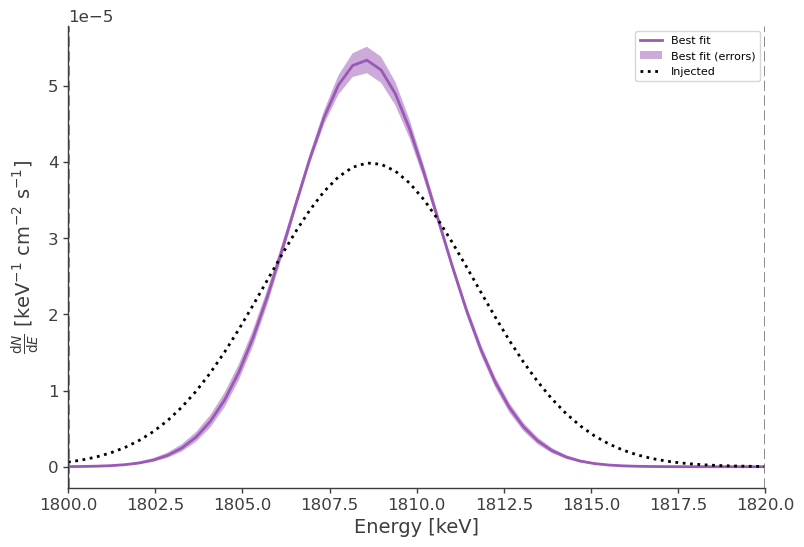

In [23]:
fig, ax = plt.subplots(figsize = (9, 6))

ax.plot(energy, flux_median, label = "Best fit")
ax.fill_between(energy, flux_lo, flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, flux_inj, color = 'black', ls = ":", label = "Injected")

if energy_selector is not None:
    if energy_cut_min is not None:
        ax.axvline(energy_cut_min.to_value(u.keV), color = 'grey', ls = '--')
    if energy_cut_max is not None:
        ax.axvline(energy_cut_max.to_value(u.keV), color = 'grey', ls = '--')

ax.set_xlabel("Energy [keV]")
ax.set_ylabel(r"$\frac{\mathrm{d}N}{\mathrm{d}E}$ [keV$^{-1}$ cm$^{-2}$ s$^{-1}$]")
ax.set_xlim(1800, 1820)

ax.legend();